# Module 1: Analyzing Tech Industry Jobs and Companies
# Module 2: Analyzing Weather of Countries using the Weather API-KEY

**#MODULE 1**

As an analyst at a tech recruitment firm, you need to gather and analyze data about tech companies and their job postings to identify industry trends and opportunities. This analysis will help inform both hiring companies and job seekers about market conditions.

Started by collecting data on the largest tech companies by revenue by scraping data from a Wikipedia-like webpage. Then, you will gather information from tech job postings, extracting data from a job search engine.

- [Step 1: Importing Modules](#step-1)
- [Step 2: Biggest Tech Companies](#step-2)
    - [Scraping the Tables](#ex1)
    - [Inspecting the Tables](#ex2)
    - [Cleaning Column Names](#ex3)
    - [Cleaning Columns](#ex4)
    - [Extracting Cities](#ex5)
- [Step 3: Analyzing Job Postings](#step-3)
    - [Getting the HTML code](#ex6a)
    - [Getting Job Listings](#ex6b)
    - [Extracting Information from HTML](#ex7)
    - [Dates](#ex8)
    - [Number of Benefits](#ex9)

In [1]:
import pandas as pd 
import requests
from bs4 import BeautifulSoup
import re 
import matplotlib.pyplot as plt
import seaborn as sns 

In [6]:
url = 'https://dlai-lc-dag.s3.us-east-2.amazonaws.com/list_of_largest_companies.html'
tables = pd.read_html(url)

In [8]:
if len(tables) >0:
    print('Downloaded tables successfully ')
else:
    print('Failed to download')

Downloaded tables successfully 


In [9]:
num_tables = len(tables)
for i in tables:
    print(tables)
tech_companies = tables[1]

[         Column                                        Explanation
0          Rank                         Rank of company by revenue
1       Company                  Name of the international company
2       Revenue  The revenue of the company in billions of USDs...
3     Employees                     Number of employees of company
4  Headquarters                 Location of company's headquarters,                 Company Revenue ($B) USD[2]  Employees[2]  \
0                Amazon              $574.8       1525000   
1                 Apple             $394.33        164000   
2              Alphabet             $282.84        190234   
3   Samsung Electronics             $234.13        270372   
4               Foxconn             $222.54        767062   
5             Microsoft             $198.27        221000   
6              Jingdong              $152.8        310000   
7               Alibaba             $130.35        204891   
8                  AT&T              $122.4    

In [12]:
tech_companies_clean = tables[1]
tecg_companies_clean = tech_companies.copy()
new_column_names = ['company','revenue_usd_billions','employee_count','country','headquarters']
tech_companies_clean.columns = new_column_names
tech_companies_clean.columns

Index(['company', 'revenue_usd_billions', 'employee_count', 'country',
       'headquarters'],
      dtype='str')

In [24]:
tech_companies_clean.dtypes

company                     str
revenue_usd_billions    float64
employee_count            int64
country                     str
headquarters                str
dtype: object

In [ ]:
tech_companies_clean['revenue_usd_billions'] = tech_companies_clean['revenue_usd_billions'].str.replace('$','')
tech_companies_clean['revenue_usd_billions'] = tech_companies_clean['revenue_usd_billions'].astype(float)
print(tech_companies_clean['revenue_usd_billions'].dtypes)
print('first values\n' ,tech_companies_clean['revenue_usd_billions'][:5])

float64
first values
 0    574.80
1    394.33
2    282.84
3    234.13
4    222.54
Name: revenue_usd_billions, dtype: float64


Text(0.5, 1.0, 'Distribution of Revenues')

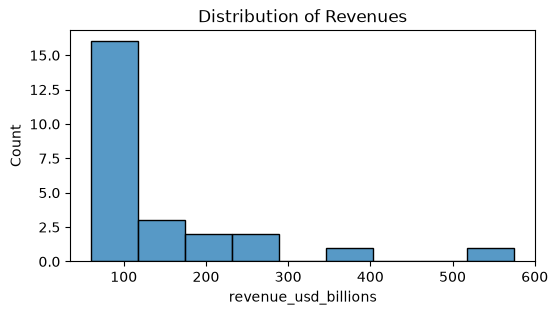

In [26]:
plt.figure(figsize=(6,3))
sns.histplot(tech_companies_clean['revenue_usd_billions'])
plt.title('Distribution of Revenues')

Pearson correlation between revenue and employee count: 0.6759066446985412


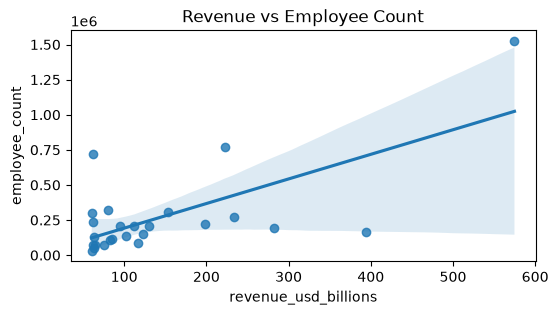

In [27]:
plt.figure(figsize=(6,3))
sns.regplot(data=tech_companies_clean, x="revenue_usd_billions", y="employee_count")
plt.title("Revenue vs Employee Count")

# print the Pearson correlation
print("Pearson correlation between revenue and employee count:", 
      tech_companies_clean["revenue_usd_billions"].corr(tech_companies_clean["employee_count"]))

In [28]:
tech_companies_clean["city"] = tech_companies_clean['headquarters'].str.split(',').str[0]
print(tech_companies_clean["city"])

0             Seattle
1           Cupertino
2       Mountain View
3               Suwon
4     New Taipei City
5             Redmond
6             Beijing
7     Yuhang District
8              Dallas
9          Menlo Park
10               Bonn
11         Round Rock
12           Shenzhen
13              Tokyo
14           Shenzhen
15              Tokyo
16    New Taipei City
17              Seoul
18        Santa Clara
19          Palo Alto
20          Hong Kong
21              Osaka
22             Dublin
23        Santa Clara
24             Armonk
Name: city, dtype: object


In [34]:
url = "https://dlai-lc-dag.s3.us-east-2.amazonaws.com/jobs.html"
response = requests.get(url)
status = response.status_code
print(status)

200


In [35]:
soup = BeautifulSoup(response.text)
print(soup.prettify()[:400])

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width, initial-scale=1.0" name="viewport"/>
  <title>
   Job Listings
  </title>
  <link href="styles_jobs.css" rel="stylesheet"/>
 </head>
 <body>
  <header>
   <h1>
    Job Marketplace
   </h1>
   <p>
    Welcome to the Job Marketplace. Explore various job listings and find your next career opportuni


In [36]:
job_listings = soup.find_all("div", class_="base-search-card_info")
jobs = []
for job in job_listings:

    # find the job title
    job_title = job.find("h3", class_="base-search-card_title").text
    
    # find the company name 
    company = job.find("h4", class_="base-search-card_subtitle").text

    # find the location
    location = job.find("span", class_="job-search-card_location").text

    # find the listing date
    list_date = job.find('p', class_="list-date").text    
    ### END CODE HERE ###

    # append the list of fields to the list of jobs
    jobs.append([job_title, company, location, list_date])
    
# create a DataFrame from the list of jobs
jobs_df = pd.DataFrame(jobs, columns=["job_title", "company", "location", "list_date"]) 
jobs_df.head()

,job_title,company,location,list_date
0,"Content Editor, IBM Think",IBM,"New York, NY",2024-12-29
1,2025 Intern â IBM Product Marketing,IBM,"New York, NY",2025-01-07
2,"Content Editor, IBM Think",IBM,"New York, NY",2024-12-30
3,Software Engineer - Frontend,LinkedIn,"Mountain View, CA",2025-01-09
4,Software Engineer - January 2025,Creyos,United States,Oct 10 2024


In [37]:
print(jobs_df.dtypes)

job_title    str
company      str
location     str
list_date    str
dtype: object


In [39]:

jobs_df["list_date"] = pd.to_datetime(jobs_df["list_date"], format="mixed")
# extract the day of the week from the list_date column
jobs_df["day_of_week"] = jobs_df["list_date"].dt.day_name()
# print the the data types of the columns to check the conversion
print(jobs_df.dtypes)

job_title                 str
company                   str
location                  str
list_date      datetime64[us]
day_of_week               str
dtype: object


Text(0.5, 1.0, 'Number of job listings per day of the week')

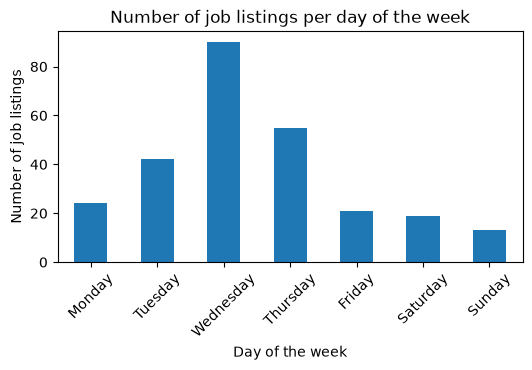

In [40]:
# Count the number of job listings per day of the week
jobs_per_day = jobs_df["day_of_week"].value_counts()
# Sort the results so you get Monday-Sunday
jobs_per_day = jobs_per_day[["Monday", "Tuesday", "Wednesday", 
                             "Thursday", "Friday", "Saturday", "Sunday"]]

# create the column chart
# set the figure size
plt.figure(figsize=(6, 3)) 
# generate the plot
jobs_per_day.plot(kind="bar")
# rotate the x-axis labels
plt.xticks(rotation=45)
# set the x-axis label
plt.xlabel("Day of the week")
# set the y-axis label
plt.ylabel("Number of job listings")
# set the title
plt.title("Number of job listings per day of the week")

**#MODULE 2**

In this module, analyze how to access the online data using an API and using the `requests` module to get the data from a URL and you will perform some basic data analysis on this data, in tracking the weather which simply wants to display the current weather at your location for you.

## Table of contents
- [Step 1: Import modules](#import-modules)
- [Step 2: Get the JSON](#get-the-json)
- [Step 3: Create a Pandas DataFrame](#create-pandas)
- [Step 4: Initial data analysis](#initial-data-analysis)
- [Step 5: Get live weather forecast](#live-forecast)

In [45]:
from dotenv import load_dotenv
import os 

In [46]:
load_dotenv()

# load API key from environment variable
API_KEY = os.getenv('RIDES_API_KEY')

### END CODE HERE ###

print(API_KEY)

None


In [56]:
url = 'https://2eraiuh.dlai.link/api/weather'
response = requests.get(url)
status = response.status_code
print(status)


200


In [57]:
data = response.json()
print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['data', 'success'])


In [58]:
weather_data = data['data']
weather_data.keys()


dict_keys(['current_condition', 'header', 'nearest_area', 'request', 'weather'])

In [59]:
df = pd.DataFrame(weather_data['weather'])
df

,astronomy,avgtempC,avgtempF,date,hourly,maxtempC,maxtempF,mintempC,mintempF,sunHour,totalSnow_cm,uvIndex
0,"[{'moon_illumination': '47', 'moon_phase': 'Wa...",-4,25,2025-02-21,"[{'DewPointC': '-9', 'DewPointF': '16', 'Feels...",0,32,-6,21,11.0,0.0,1
1,"[{'moon_illumination': '38', 'moon_phase': 'Wa...",-2,29,2025-02-22,"[{'DewPointC': '-11', 'DewPointF': '13', 'Feel...",5,40,-7,19,11.0,0.0,1
2,"[{'moon_illumination': '28', 'moon_phase': 'Wa...",1,33,2025-02-23,"[{'DewPointC': '-6', 'DewPointF': '22', 'Feels...",5,42,-3,26,10.0,0.0,1


In [60]:
df.columns

Index(['astronomy', 'avgtempC', 'avgtempF', 'date', 'hourly', 'maxtempC',
       'maxtempF', 'mintempC', 'mintempF', 'sunHour', 'totalSnow_cm',
       'uvIndex'],
      dtype='str')

In [53]:
df=pd.DataFrame(data['results'])
df.columns

Index(['status', 'city', 'state', 'country', 'classification', 'openfda',
       'product_type', 'event_id', 'recalling_firm', 'address_1', 'address_2',
       'postal_code', 'voluntary_mandated', 'initial_firm_notification',
       'distribution_pattern', 'recall_number', 'product_description',
       'product_quantity', 'reason_for_recall', 'recall_initiation_date',
       'center_classification_date', 'termination_date', 'report_date',
       'code_info', 'more_code_info'],
      dtype='str')

In [61]:
numeric_columns = ['maxtempC',
       'maxtempF', 'mintempC', 'mintempF', 'sunHour', 'totalSnow_cm',
       'uvIndex','avgtempC', 'avgtempF']
df[numeric_columns] = df[numeric_columns].astype(float)
df['date'] = pd.to_datetime(df['date'])
df.set_index(df['date'], inplace=True)
df.head()
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3 entries, 2025-02-21 to 2025-02-23
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   astronomy     3 non-null      object        
 1   avgtempC      3 non-null      float64       
 2   avgtempF      3 non-null      float64       
 3   date          3 non-null      datetime64[us]
 4   hourly        3 non-null      object        
 5   maxtempC      3 non-null      float64       
 6   maxtempF      3 non-null      float64       
 7   mintempC      3 non-null      float64       
 8   mintempF      3 non-null      float64       
 9   sunHour       3 non-null      float64       
 10  totalSnow_cm  3 non-null      float64       
 11  uvIndex       3 non-null      float64       
dtypes: datetime64[us](1), float64(9), object(2)
memory usage: 312.0+ bytes


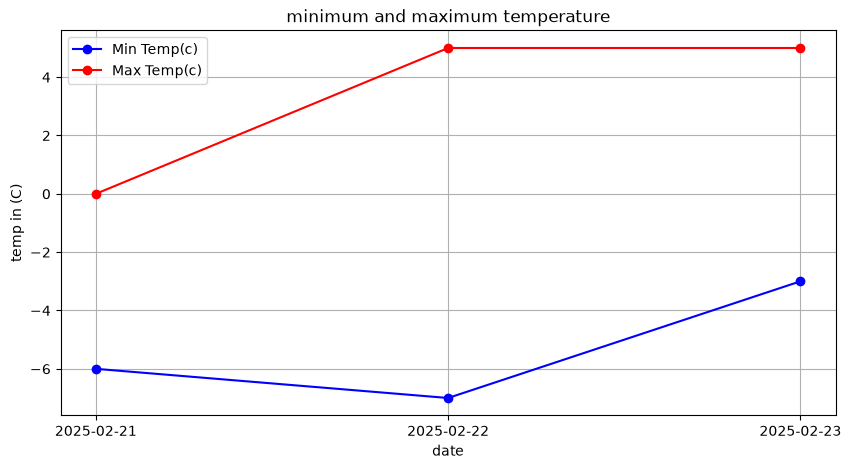

In [64]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['mintempC'], label = 'Min Temp(c)', marker='o', color='blue')
plt.plot(df.index, df['maxtempC'], label= 'Max Temp(c)', marker='o', color='red')
plt.title('minimum and maximum temperature')
plt.xlabel('date')
plt.ylabel('temp in (C)')
plt.xticks(df.index, df.index.strftime('%Y-%m-%d'))
plt.grid(True)
plt.legend()
plt.show()

In [65]:
city = 'Sydney'
url_wttr = f'http://wttr.in/{city}?format=j1'
response_wttr = requests.get(url_wttr)
status = response_wttr.status_code
weather_data = response.json()
weather_data = weather_data['data']
df = pd.DataFrame(weather_data['weather'])
df.head()

,astronomy,avgtempC,avgtempF,date,hourly,maxtempC,maxtempF,mintempC,mintempF,sunHour,totalSnow_cm,uvIndex
0,"[{'moon_illumination': '47', 'moon_phase': 'Wa...",-4,25,2025-02-21,"[{'DewPointC': '-9', 'DewPointF': '16', 'Feels...",0,32,-6,21,11.0,0.0,1
1,"[{'moon_illumination': '38', 'moon_phase': 'Wa...",-2,29,2025-02-22,"[{'DewPointC': '-11', 'DewPointF': '13', 'Feel...",5,40,-7,19,11.0,0.0,1
2,"[{'moon_illumination': '28', 'moon_phase': 'Wa...",1,33,2025-02-23,"[{'DewPointC': '-6', 'DewPointF': '22', 'Feels...",5,42,-3,26,10.0,0.0,1


In [66]:
city='Sydney'
url_wttr_2 = f"http://wttr.in/{city}"
response_wttr_2 = requests.get(url_wttr_2)
print(response_wttr_2.text)

Weather report: Sydney

   _`/"".-.     Patchy rain nearby
    ,\_(   ).   +11(9) °C
     /(___(__)  ↗ 10 km/h
       ‘ ‘ ‘ ‘  10 km
      ‘ ‘ ‘ ‘   0.0 mm
                                                       ┌─────────────┐
┌──────────────────────────────┬───────────────────────┤  Thu 30 Jul ├───────────────────────┬──────────────────────────────┐
│            Morning           │             Noon      └──────┬──────┘     Evening           │             Night            │
├──────────────────────────────┼──────────────────────────────┼──────────────────────────────┼──────────────────────────────┤
│     \   /     Sunny          │     \   /     Sunny          │     \   /     Clear          │  _`/"".-.     Patchy rain ne…│
│      .-.      +11(9) °C      │      .-.      +14(13) °C     │      .-.      +13(11) °C     │   ,\_(   ).   12 °C          │
│   ― (   ) ―   ↗ 13-16 km/h   │   ― (   ) ―   ↑ 15-18 km/h   │   ― (   ) ―   ↖ 14-22 km/h   │    /(___(__)  ↑ 9-16 km/h    │
│      `-’      1